In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
!pip install --upgrade scipy
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 43.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.2 which is incompatible.
ydata-profiling 4.16.1 requires scipy<1.16,>=1.4.1, but you have scipy 1.16.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.

From the imported datasets we will now open them to see their description and perform EDA first.

In [2]:
import pandas as pd
import numpy as np

training = pd.read_csv('/kaggle/input/house-prices/train.csv')
test = pd.read_csv('/kaggle/input/house-prices/test.csv')

y = training['SalePrice']
x = training.drop('SalePrice', axis=1)

print(training, test)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Utilities  ... PoolArea PoolQC  Fe

Importing sns and matplotlib for clarification

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


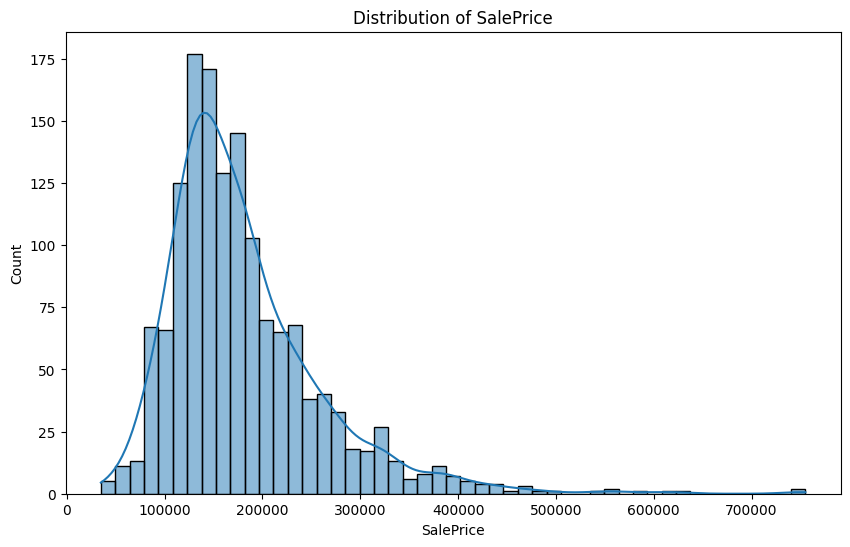

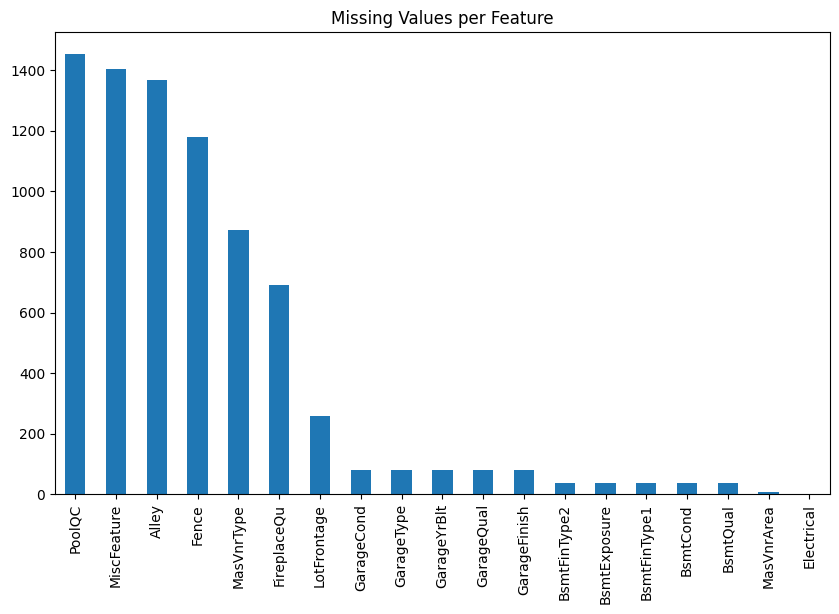

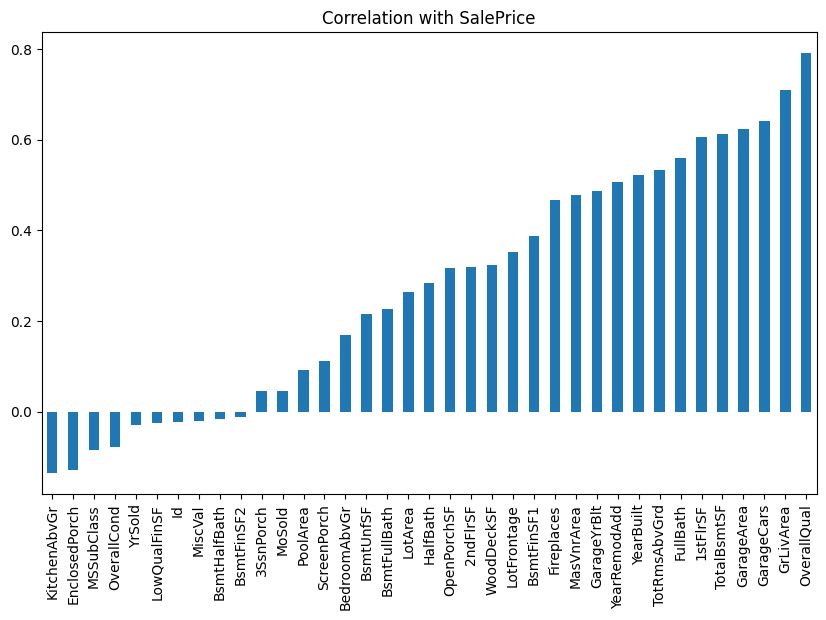

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(y, kde=True)
plt.title("Distribution of SalePrice")
plt.show()

missing = x.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
missing.plot(kind="bar")
plt.title("Missing Values per Feature")
plt.show()

numeric_feats = x.select_dtypes(include=["int64", "float64"])
corr = numeric_feats.corrwith(y)

plt.figure(figsize=(10, 6))
corr.sort_values().plot(kind="bar")
plt.title("Correlation with SalePrice")
plt.show()

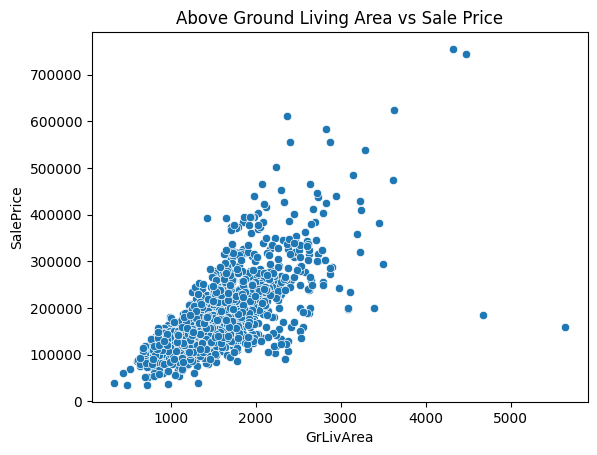

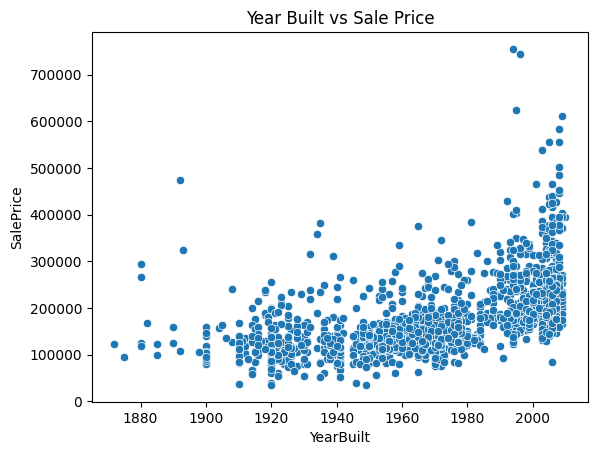

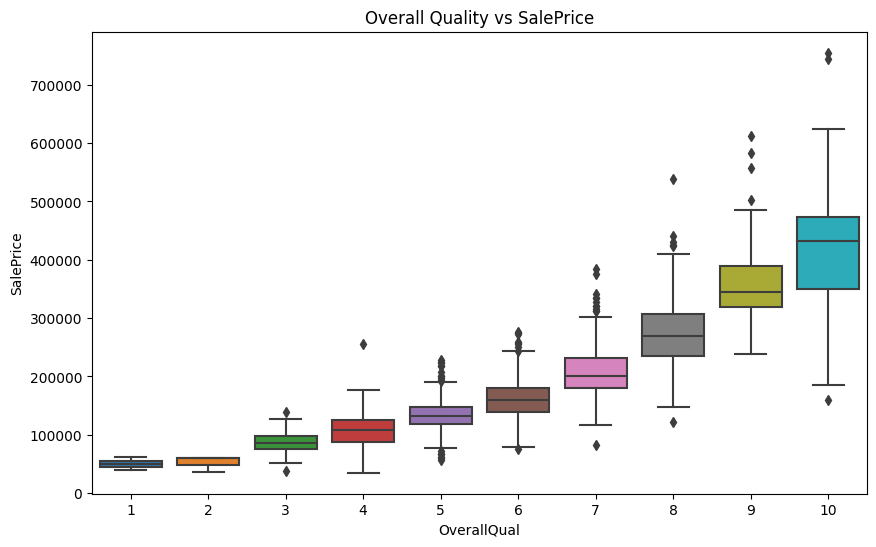

In [4]:

sns.scatterplot(x=x['GrLivArea'],y=y)
plt.title('Above Ground Living Area vs Sale Price')
plt.show()


sns.scatterplot(x=x['YearBuilt'],y=y)
plt.title('Year Built vs Sale Price')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=x["OverallQual"], y=y)
plt.title("Overall Quality vs SalePrice")
plt.show()

Now, comes the pre processing. Unlike the sentiment 160, this requires pipelines for preprocessing for different cases: numeric, categorical and combination.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

x_train, x_valid, y_train, y_valid = train_test_split(x,y,test_size=0.2, random_state=42)
numeric_features = x_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = x_train.select_dtypes(include=["object"]).columns

# Numeric pipeline: fill missing, scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: fill missing, one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("regressor", Ridge(alpha=0.1,  random_state=42))])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 29227.73731809619
Validation R^2 0.888627862015153


In [7]:
from sklearn.linear_model import LinearRegression


model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("linearregression", LinearRegression())])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)



Validation RMSE: 73079585820537.84
Validation R^2 -6.962710215241129e+17


In [8]:
from sklearn.linear_model import Lasso

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("lasso", Lasso(alpha=0.1,random_state=42))])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 28365.483263974726
Validation R^2 0.8951021613598498


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.474e+10, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [9]:
from sklearn.ensemble import GradientBoostingRegressor

chosen_model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("gradientboosting", GradientBoostingRegressor())])

chosen_model.fit(x_train, y_train)
chosen_preds = chosen_model.predict(x_valid)

rmse = mean_squared_error(y_valid, chosen_preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, chosen_preds)
print('Validation R^2', r_2)

Validation RMSE: 26708.199813365965
Validation R^2 0.907001616619344


In [10]:
from xgboost import XGBRegressor

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("xgboost", XGBRegressor())])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 27591.74276413314
Validation R^2 0.9007468198616183


In [11]:
from sklearn.ensemble import AdaBoostRegressor

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("adaboost", AdaBoostRegressor())])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 34707.27060624158
Validation R^2 0.8429539239405267


In [12]:
from catboost import CatBoostRegressor

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("catboost", CatBoostRegressor(
                                                      verbose=0))])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 26974.88973746217
Validation R^2 0.9051351068137837


In [13]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

model = Pipeline(steps=[("preprocessor", preprocessor),
                        ("lgb", LGBMRegressor(verbose=0))])

model.fit(x_train, y_train)
preds = model.predict(x_valid)

rmse = mean_squared_error(y_valid, preds, squared=False)
print("Validation RMSE:", rmse)

r_2 = r2_score(y_valid, preds)
print('Validation R^2', r_2)

Validation RMSE: 29347.33226547748
Validation R^2 0.8877145654778898


In [14]:
chosen_model.fit(x,y)

chosen_pred = chosen_model.predict(test)

submission = pd.DataFrame({
    "Id": test["Id"],           
    "SalePrice": chosen_pred
})

submission.to_csv('submission.csv',index=False)